In [17]:
import pandas as pd

In [18]:
# Creating a small student dataset for practice

student_data = {
    "Attendance": [92, 75, 88, 60, 95, 70, 85, 55, 98, 80],
    "Assignment": [90, 65, 85, 50, 96, 60, 82, 45, 99, 75],
    "Participation": ["High", "Medium", "High", "Low", "High",
                      "Medium", "Medium", "Low", "High", "Medium"],
    "ExamScore": [88, 62, 84, 48, 95, 58, 80, 40, 97, 72]
}

students = pd.DataFrame(student_data)

students.head()

,Attendance,Assignment,Participation,ExamScore
0,92,90,High,88
1,75,65,Medium,62
2,88,85,High,84
3,60,50,Low,48
4,95,96,High,95


In [19]:
# Check whether there are any missing values

print("Missing Values")
print(students.isnull().sum())

Missing Values
Attendance       0
Assignment       0
Participation    0
ExamScore        0
dtype: int64


In [20]:
# Convert text values into numbers

encoder = LabelEncoder()

students["Participation"] = encoder.fit_transform(students["Participation"])

print(students.head())

   Attendance  Assignment  Participation  ExamScore
0          92          90              0         88
1          75          65              2         62
2          88          85              0         84
3          60          50              1         48
4          95          96              0         95


In [21]:
# Display some basic statistics

print(students.describe())

       Attendance  Assignment  Participation  ExamScore
count   10.000000   10.000000      10.000000  10.000000
mean    79.800000   74.700000       1.000000  72.400000
std     14.649991   18.973959       0.942809  19.755168
min     55.000000   45.000000       0.000000  40.000000
25%     71.250000   61.250000       0.000000  59.000000
50%     82.500000   78.500000       1.000000  76.000000
75%     91.000000   88.750000       2.000000  87.000000
max     98.000000   99.000000       2.000000  97.000000


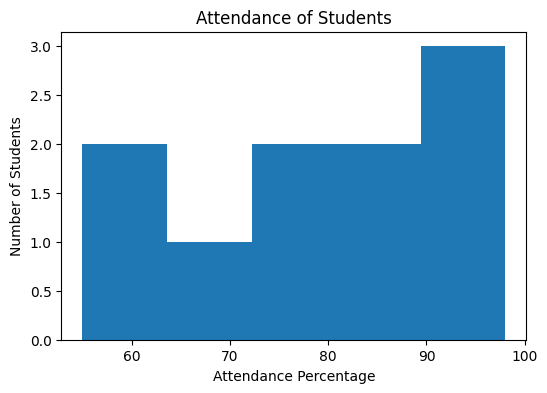

In [22]:
plt.figure(figsize=(6,4))

plt.hist(students["Attendance"], bins=5)

plt.title("Attendance of Students")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")

plt.show()

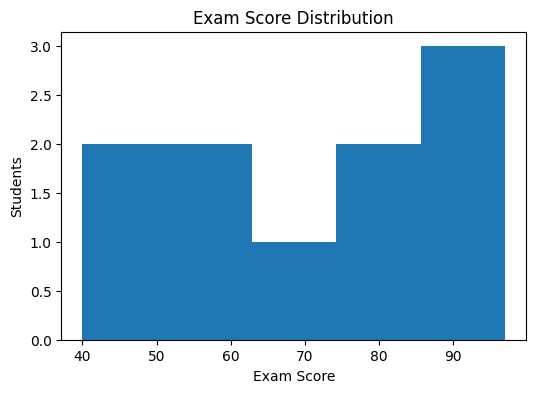

In [23]:
plt.figure(figsize=(6,4))

plt.hist(students["ExamScore"], bins=5)

plt.title("Exam Score Distribution")
plt.xlabel("Exam Score")
plt.ylabel("Students")

plt.show()

In [24]:
# Students scoring below 60 are marked as at risk

students["AtRisk"] = students["ExamScore"].apply(lambda score: 1 if score < 60 else 0)

students.head()

,Attendance,Assignment,Participation,ExamScore,AtRisk
0,92,90,0,88,0
1,75,65,2,62,0
2,88,85,0,84,0
3,60,50,1,48,1
4,95,96,0,95,0


In [25]:
print("Students Who Need Additional Guidance\n")

at_risk = students[students["AtRisk"] == 1]

print(at_risk)

Students Who Need Additional Guidance

   Attendance  Assignment  Participation  ExamScore  AtRisk
3          60          50              1         48       1
5          70          60              2         58       1
7          55          45              1         40       1


In [26]:
# Select the input features

X = students[["Attendance", "Assignment", "Participation"]]

# Target column

y = students["AtRisk"]

In [27]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
# Create the model

tree_model = DecisionTreeClassifier(random_state=42)

# Train it using the training data

tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [14]:
# Predict the test data

predicted_result = tree_model.predict(X_test)

print(predicted_result)

[0 1]


In [29]:
# Calculate the accuracy of the model

accuracy = accuracy_score(y_test, predicted_result)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 50.0 %


In [30]:
print("\nClassification Report\n")

print(classification_report(y_test, predicted_result))


Classification Report

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



C:\Users\sshar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sshar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sshar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
